In [1]:
import h5py
import numpy as np
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers
import matplotlib.pyplot as plt
from bm3d import bm3d_rgb, BM3DProfile
import sys
module_dir = "/global/u2/k/kberard/SCGSR/Research/Diamond/stock_models/bm3d-4.0.3/bm3d-4.0.3/examples" 
sys.path.insert(0, module_dir)
from experiment_funcs import get_experiment_noise, get_psnr, get_cropped_psnr
from PIL import Image
import math
import torch
import torch.nn as nn
import torch.optim as optim
from thop import profile
from einops import rearrange 
from einops.layers.torch import Rearrange, Reduce
from timm.models.layers import trunc_normal_, DropPath

module_dir_scu = "/global/u2/k/kberard/SCGSR/Research/Diamond/stock_models/SCUNet" 
sys.path.insert(0, module_dir_scu)
from models.network_scunet import SCUNet as SCUNet
from torch.utils.data import Dataset
from utils import utils_image as util
import joblib
from sklearn.preprocessing import MinMaxScaler

2026-01-23 08:51:05.829617: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769187065.842906 1026520 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769187065.847017 1026520 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1769187065.858839 1026520 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769187065.858850 1026520 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769187065.858852 1026520 computation_placer.cc:177] computation placer alr

In [3]:
model_samp = str(240700000)
print("modules loaded")


modules loaded


In [4]:

with h5py.File('/global/u2/k/kberard/SCGSR/Research/Diamond/Data/density_tot_ref.h5', 'r') as file:
    ref_d = file['density'][:]

In [5]:
#### test file #######
with h5py.File('/pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/density_tot_vmc_mean_0000655360.h5', 'r') as file:
    #print("Keys: %s" % file.keys())
    test_d = file['density'][:]

In [2]:
def D_JS(p1,p2,tol=1e-16):
    p1= p1/np.sum(p1)
    p2=p2/np.sum(p2)
    pm = (p1+p2)/2
    p1_nonzero = np.abs(p1)>tol
    p2_nonzero = np.abs(p2)>tol
    p1  = np.abs(p1[p1_nonzero])
    pm1 = np.abs(pm[p1_nonzero])
    p2  = np.abs(p2[p2_nonzero])
    pm2 = np.abs(pm[p2_nonzero])
    d = .5*( (p1*np.log(p1/pm1)).sum() + (p2*np.log(p2/pm2)).sum() )
    d /= np.log(2) # normalize to max of 1
    return d

In [7]:
def encode_voxel_to_rgb(test_d, save_path='slice_scalers.npz'):
    """
    Normalize each XY slice independently and encode to RGB (repeated channels).
    Saves (min, max) for each slice for reconstruction.
    
    Returns:
        rgb_volume: (64, 64, 64, 3)
    """
    rgb_volume = np.zeros((64, 64, 64, 3), dtype=np.float32)
    mins = []
    maxs = []

    for i in range(64):
        slice_2d = test_d[i, :, :]
        s_min = float(slice_2d.min())
        s_max = float(slice_2d.max())

        if s_max == s_min:
            s_max = s_min + 1e-6  # Avoid divide-by-zero for flat slices

        normed = (slice_2d - s_min) / (s_max - s_min)
        rgb_volume[i, :, :, :] = np.stack([normed]*3, axis=-1)  # (64, 64, 3)

        mins.append(s_min)
        maxs.append(s_max)

    np.savez(save_path, mins=np.array(mins), maxs=np.array(maxs))
    return rgb_volume  # shape: (64, 64, 64, 3)


In [8]:
def decode_rgb_to_voxel(rgb_volume, save_path='slice_scalers.npz'):
    """
    Decode per-slice normalized RGB volume back into scalar 3D volume.
    Assumes all RGB channels are identical.
    
    Args:
        rgb_volume: shape (64, 64, 64, 3)
    """
    data = np.load(save_path)
    mins = data['mins']
    maxs = data['maxs']

    test_d = np.zeros((64, 64, 64), dtype=np.float32)

    for i in range(64):
        rgb_slice = rgb_volume[i]  # (64, 64, 3)
        gray = rgb_slice[:, :, 0]
        restored = gray * (maxs[i] - mins[i]) + mins[i]
        test_d[i] = restored

    return test_d


In [9]:
print("enc dec loaded")

enc dec loaded


In [10]:
############### scunet_Pretrained ###############

def scunet_pre_test_pipeline(test_d, ref_d):
    # Encode
    test_rgb = encode_voxel_to_rgb(test_d)
    ref_rgb  = encode_voxel_to_rgb(ref_d)

    # Denoise each of 64 RGB slices
    denoised_rgb = np.zeros_like(test_rgb)
    # Load pretrained model
    model = SCUNet(in_nc=3, config=[4, 4, 4, 4, 4, 4, 4], dim=64)
    model_path = '/global/u2/k/kberard/SCGSR/Research/Diamond/stock_models/SCUNet/model_zoo/scunet_color_25.pth'  # Adjust if needed
    model.load_state_dict(torch.load(model_path, map_location='cpu'), strict=True)
    model.eval()
    model.to('cuda' if torch.cuda.is_available() else 'cpu')

    def denoise_with_scunet(rgb_image_np, model, device='cuda'):
        """
        Args:
            rgb_image_np: (H, W, 3), float32 or float64, values in [0,1]
            model: SCUNet model
            device: 'cuda' or 'cpu'
        
        Returns:
            Denoised image (H, W, 3), uint8
        """
        # Make sure image is float32 in [0,1]
        img = rgb_image_np.astype(np.float32)
        img_tensor = util.single2tensor4(img).to(device)
        with torch.no_grad():
            output_tensor = model(img_tensor)
        output_np = util.tensor2single(output_tensor)
        return np.clip(output_np.transpose(1, 2, 0), 0, 1)
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    

    for i in range(test_rgb.shape[0]):
        
        noisy_slice = test_rgb[i]

        #gray_input = noisy_slice[:, :, 0]  # just one channel
        #denoised_gray = bm3d(gray_input, sigma_psd=sigma)
        #denoised_rgb[i] = np.stack([denoised_gray] * 3, axis=-1)
        denoise =denoise_with_scunet(noisy_slice, model, device=device)
        denoised_rgb[i] = np.transpose(denoise, (0,2,1))
        

    ####

    # Reconstruct full 3D volume
    denoised_d = decode_rgb_to_voxel(denoised_rgb)
    #denoised_d = np.mean(denoised_rgb,axis=3)
    #print(np.linalg.norm(denoised_d))
    #print("ref")

    #print(np.linalg.norm(ref_d))
    #print(np.linalg.norm(np.sum(np.mean(ref_rgb,axis=3),axis=0)))

    # --- Evaluation ---
    print("\n>>> Evaluation Metrics 2D")
    jsd_noisy_2d = D_JS(test_d,
        ref_d
    )
    jsd_denoised_2d = D_JS(
        denoised_d,ref_d
    )

    norm_noisy_2d = np.linalg.norm(test_d - ref_d)
    norm_denoised_2d = np.linalg.norm(denoised_d - ref_d)

    print(f"2-norm (noisy vs ref):     {norm_noisy_2d:.4f}")
    print(f"2-norm (denoised vs ref): {norm_denoised_2d:.4f}")
    print(f"JSD   (noisy vs ref):     {jsd_noisy_2d:.6f}")
    print(f"JSD   (denoised vs ref):  {jsd_denoised_2d:.6f}")

    ##########
    # --- Evaluation ---
    print("\n>>> Evaluation Metrics 3D")
    jsd_noisy = D_JS(test_d,
        ref_d
    )
    jsd_denoised = D_JS(
        denoised_d,ref_d
    )

    norm_noisy = np.linalg.norm(test_d - ref_d)
    norm_denoised = np.linalg.norm(denoised_d - ref_d)

    print(f"2-norm (noisy vs ref):     {norm_noisy:.4f}")
    print(f"2-norm (denoised vs ref): {norm_denoised:.4f}")
    print(f"JSD   (noisy vs ref):     {jsd_noisy:.6f}")
    print(f"JSD   (denoised vs ref):  {jsd_denoised:.6f}")
    #########

    # --- Plot example slices ---
    slice_idx = 32
    plt.figure(figsize=(12, 6))
    titles = ['Noisy', 'Denoised', 'Reference']
    data = [test_d[slice_idx], denoised_d[slice_idx], ref_d[slice_idx]]
    for i in range(3):
        plt.subplot(1, 3, i+1)
        plt.imshow(data[i], cmap='viridis')
        plt.title(f"{titles[i]} (z={slice_idx})")
        plt.axis('off')
    plt.tight_layout()
    plt.show()
    return(denoised_d,jsd_denoised_2d)


In [11]:
print("scunet pretrained loaded")

scunet pretrained loaded


In [12]:
############### scunet_Trained ###############

def scunet_trained_test_pipeline(test_d, ref_d):
    # Encode
    test_rgb = encode_voxel_to_rgb(test_d)
    ref_rgb  = encode_voxel_to_rgb(ref_d)

    # Denoise each of 64 RGB slices
    denoised_rgb = np.zeros_like(test_rgb)
    
    torch.serialization.add_safe_globals([SCUNet])
    model = torch.load('/pscratch/sd/k/kberard/SCGSR/3D_VMC/Model_Train_dat/Scunet_trained_Models/'+model_samp+'_scunet_trained', weights_only=False, map_location=torch.device("cpu"))
    model.eval()

    def single2tensor4(img):
        """
        Convert HWC image [0,1] float32 to NCHW tensor
        """
        img_tensor = torch.from_numpy(np.transpose(img, (2, 0, 1))).float().unsqueeze(0)  # shape (1, 3, H, W)
        return img_tensor
    def tensor2single(tensor):
        """
        Convert NCHW or CHW tensor to HWC numpy array, clipped to [0,1]
        """
        tensor = tensor.squeeze().cpu().detach().numpy()
        if tensor.ndim == 3:
            img_np = np.transpose(tensor, (1, 2, 0))  # CHW -> HWC
        else:
            img_np = tensor  # in case it's grayscale
        return np.clip(img_np, 0, 1)


    def denoise_with_scunet(rgb_image_np, model, device='cpu'):
        """
        Denoise a single RGB image using SCUNet.
    
        Args:
            rgb_image_np: (H, W, 3), float32, values in [0,1]
            model: PyTorch SCUNet model
            device: 'cuda' or 'cpu'
    
        Returns:
            Denoised image (H, W, 3), float32 in [0,1]
        """
        img = rgb_image_np.astype(np.float32)
        
        # Ensure range is [0, 1]
        img = np.clip(img, 0, 1)
    
        img_tensor = single2tensor4(img).to(device)
    
        with torch.no_grad():
            output_tensor = model(img_tensor)
    
        output_np = tensor2single(output_tensor)
        return output_np

    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    


    
    for i in range(test_rgb.shape[0]):
        noisy_slice = test_rgb[i]  # shape: (H, W, 3)
    
        denoised = denoise_with_scunet(noisy_slice, model, device=device)  # shape: (H, W, 3)
    
        if np.isnan(denoised).any():
            print(f"⚠️ NaNs detected in denoised slice {i}")
    
        denoised_rgb[i] = denoised



        

    ####

    # Reconstruct full 3D volume
    denoised_d = decode_rgb_to_voxel(denoised_rgb)


    # --- Evaluation ---
    print("\n>>> Evaluation Metrics 2D")
    jsd_noisy_2d = D_JS(test_d,
       ref_d
    )
    jsd_denoised_2d = D_JS(
        denoised_d,ref_d
    )

    norm_noisy_2d = np.linalg.norm(test_d - ref_d)
    norm_denoised_2d = np.linalg.norm(denoised_d -ref_d)

    print(f"2-norm (noisy vs ref):     {norm_noisy_2d:.4f}")
    print(f"2-norm (denoised vs ref): {norm_denoised_2d:.4f}")
    print(f"JSD   (noisy vs ref):     {jsd_noisy_2d:.6f}")
    print(f"JSD   (denoised vs ref):  {jsd_denoised_2d:.6f}")

    ##########
    # --- Evaluation ---
    print("\n>>> Evaluation Metrics 3D")
    jsd_noisy = D_JS(test_d,
        ref_d
    )
    jsd_denoised = D_JS(
        denoised_d,ref_d
    )

    norm_noisy = np.linalg.norm(test_d - ref_d)
    norm_denoised = np.linalg.norm(denoised_d - ref_d)

    print(f"2-norm (noisy vs ref):     {norm_noisy:.4f}")
    print(f"2-norm (denoised vs ref): {norm_denoised:.4f}")
    print(f"JSD   (noisy vs ref):     {jsd_noisy:.6f}")
    print(f"JSD   (denoised vs ref):  {jsd_denoised:.6f}")
    #########

    # --- Plot example slices ---
    slice_idx = 32
    plt.figure(figsize=(12, 6))
    titles = ['Noisy', 'Denoised', 'Reference']
    data = [test_d[slice_idx], denoised_d[slice_idx], ref_d[slice_idx]]
    for i in range(3):
        plt.subplot(1, 3, i+1)
        plt.imshow(data[i], cmap='viridis')
        plt.title(f"{titles[i]} (z={slice_idx})")
        plt.axis('off')
    plt.tight_layout()
    plt.show()
    return(denoised_d,jsd_denoised_2d)


In [13]:
print("scunet trained loaded")

scunet trained loaded


In [14]:
############## scunet_TL ##################


def scunet_FT_test_pipeline(test_d, ref_d):
    # Set device first
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    # Encode
    test_rgb = encode_voxel_to_rgb(test_d)
    ref_rgb  = encode_voxel_to_rgb(ref_d)

    # Denoise each of 64 RGB slices
    denoised_rgb = np.zeros_like(test_rgb)

    # Optional: only needed if loading full model with class definition
    torch.serialization.add_safe_globals([SCUNet])

    # Load model AFTER setting device
    model = torch.load('/pscratch/sd/k/kberard/SCGSR/3D_VMC/Model_Train_dat/Scunet_FT_Models/'+model_samp+'_scunet_FT', map_location='cpu', weights_only=False)
    model.eval()

    def single2tensor4(img):
        """
        Convert HWC image [0,1] float32 to NCHW tensor
        """
        img_tensor = torch.from_numpy(np.transpose(img, (2, 0, 1))).float().unsqueeze(0)  # shape (1, 3, H, W)
        return img_tensor
    def tensor2single(tensor):
        """
        Convert NCHW or CHW tensor to HWC numpy array, clipped to [0,1]
        """
        tensor = tensor.squeeze().cpu().detach().numpy()
        if tensor.ndim == 3:
            img_np = np.transpose(tensor, (1, 2, 0))  # CHW -> HWC
        else:
            img_np = tensor  # in case it's grayscale
        return np.clip(img_np, 0, 1)


    def denoise_with_scunet(rgb_image_np, model, device='cuda'):
        """
        Denoise a single RGB image using SCUNet.
    
        Args:
            rgb_image_np: (H, W, 3), float32, values in [0,1]
            model: PyTorch SCUNet model
            device: 'cuda' or 'cpu'
    
        Returns:
            Denoised image (H, W, 3), float32 in [0,1]
        """
        img = rgb_image_np.astype(np.float32)
        
        # Ensure range is [0, 1]
        img = np.clip(img, 0, 1)
    
        img_tensor = single2tensor4(img).to(device)
    
        with torch.no_grad():
            output_tensor = model(img_tensor)
    
        output_np = tensor2single(output_tensor)
        return output_np

    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    


    
    for i in range(test_rgb.shape[0]):
        noisy_slice = test_rgb[i]  # shape: (H, W, 3)
    
        denoised = denoise_with_scunet(noisy_slice, model, device=device)  # shape: (H, W, 3)
    
        if np.isnan(denoised).any():
            print(f"⚠️ NaNs detected in denoised slice {i}")
    
        denoised_rgb[i] = denoised



        

    ####

    # Reconstruct full 3D volume
    denoised_d = decode_rgb_to_voxel(denoised_rgb)

    
    # --- Evaluation ---
    print("\n>>> Evaluation Metrics 2D")
    jsd_noisy_2d = D_JS(test_d,
        ref_d
    )
    jsd_denoised_2d = D_JS(
        denoised_d,ref_d
    )

    norm_noisy_2d = np.linalg.norm(test_d - ref_d)
    norm_denoised_2d = np.linalg.norm(denoised_d - ref_d)

    print(f"2-norm (noisy vs ref):     {norm_noisy_2d:.4f}")
    print(f"2-norm (denoised vs ref): {norm_denoised_2d:.4f}")
    print(f"JSD   (noisy vs ref):     {jsd_noisy_2d:.6f}")
    print(f"JSD   (denoised vs ref):  {jsd_denoised_2d:.6f}")

    ##########
    # --- Evaluation ---
    print("\n>>> Evaluation Metrics 3D")
    jsd_noisy = D_JS(test_d,
        ref_d
    )
    jsd_denoised = D_JS(
        denoised_d,ref_d
    )

    norm_noisy = np.linalg.norm(test_d - ref_d)
    norm_denoised = np.linalg.norm(denoised_d - ref_d)

    print(f"2-norm (noisy vs ref):     {norm_noisy:.4f}")
    print(f"2-norm (denoised vs ref): {norm_denoised:.4f}")
    print(f"JSD   (noisy vs ref):     {jsd_noisy:.6f}")
    print(f"JSD   (denoised vs ref):  {jsd_denoised:.6f}")
    #########

    # --- Plot example slices ---
    slice_idx = 32
    plt.figure(figsize=(12, 6))
    titles = ['Noisy', 'Denoised', 'Reference']
    data = [test_d[slice_idx], denoised_d[slice_idx], ref_d[slice_idx]]
    for i in range(3):
        plt.subplot(1, 3, i+1)
        plt.imshow(data[i], cmap='viridis')
        plt.title(f"{titles[i]} (z={slice_idx})")
        plt.axis('off')
    plt.tight_layout()
    plt.show()
    return(denoised_d,jsd_denoised_2d)


In [15]:
print("scunet TL loaded")

scunet TL loaded


In [16]:
from keras.models import load_model
import keras

############# Nature #####################
import tensorflow as tf
@tf.keras.utils.register_keras_serializable()
class OnesLikeLayer(tf.keras.layers.Layer):
    def call(self, inputs):
        return tf.ones_like(inputs)
def ones_like_fn(a):
    return tf.ones_like(a)
# Now load the model
nature_mod = tf.keras.models.load_model(
    '/pscratch/sd/k/kberard/SCGSR/3D_VMC/Model_Train_dat/Nature_Models/'+model_samp+'_Nature.keras',
    custom_objects={'ones_like_fn': ones_like_fn}
)

from keras.layers import Lambda

layer = Lambda(lambda x: x, output_shape=(64, 64, 3))
def Nature_test_pipeline(test_d, ref_d):
    test_rgb = encode_voxel_to_rgb(test_d)
    denoised_rgb = CAE_mod.predict(test_rgb)
    ref_rgb  = encode_voxel_to_rgb(ref_d)
    print(denoised_rgb.shape,"x_test_shape")

    # Denoise each of 64 RGB slices
    #denoised_rgb = np.zeros_like(test_rgb)
    
    #denoised_rgb = nature_mod.predict(noisy_slice)  # shape: (H, W, 3)
    


    # Reconstruct full 3D volume
    denoised_d = decode_rgb_to_voxel(denoised_rgb)


    # --- Evaluation ---
    print("\n>>> Evaluation Metrics 2D")
    jsd_noisy_2d = D_JS(test_d,
        ref_d
    )
    jsd_denoised_2d = D_JS(
        denoised_d,ref_d
    )

    norm_noisy_2d = np.linalg.norm(test_d - ref_d)
    norm_denoised_2d = np.linalg.norm(denoised_d - ref_d)

    print(f"2-norm (noisy vs ref):     {norm_noisy_2d:.4f}")
    print(f"2-norm (denoised vs ref): {norm_denoised_2d:.4f}")
    print(f"JSD   (noisy vs ref):     {jsd_noisy_2d:.6f}")
    print(f"JSD   (denoised vs ref):  {jsd_denoised_2d:.6f}")

    ##########
    # --- Evaluation ---
    print("\n>>> Evaluation Metrics 3D")
    jsd_noisy = D_JS(test_d,
        ref_d
    )
    jsd_denoised = D_JS(
        denoised_d,ref_d
    )

    norm_noisy = np.linalg.norm(test_d - ref_d)
    norm_denoised = np.linalg.norm(denoised_d - ref_d)

    print(f"2-norm (noisy vs ref):     {norm_noisy:.4f}")
    print(f"2-norm (denoised vs ref): {norm_denoised:.4f}")
    print(f"JSD   (noisy vs ref):     {jsd_noisy:.6f}")
    print(f"JSD   (denoised vs ref):  {jsd_denoised:.6f}")
    #########

    # --- Plot example slices ---
    slice_idx = 32
    plt.figure(figsize=(12, 6))
    titles = ['Noisy', 'Denoised', 'Reference']
    data = [test_d[slice_idx], denoised_d[slice_idx], ref_d[slice_idx]]
    for i in range(3):
        plt.subplot(1, 3, i+1)
        plt.imshow(data[i], cmap='viridis')
        plt.title(f"{titles[i]} (z={slice_idx})")
        plt.axis('off')
    plt.tight_layout()
    plt.show()
    return(denoised_d,jsd_denoised_2d)


I0000 00:00:1767045506.423010 1447908 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 38366 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:41:00.0, compute capability: 8.0


In [17]:
print("natrure model loaded")

natrure model loaded


In [18]:
############### CAE_img_enc ###############
from keras.models import load_model
import keras
keras.config.enable_unsafe_deserialization()
CAE_mod = load_model('/pscratch/sd/k/kberard/SCGSR/3D_VMC/Model_Train_dat/CAE_img_Models/'+model_samp+'_2d_CAE_IMG_enc.keras')
from keras.layers import Lambda

def CAE_test_pipeline(test_d, ref_d):
    # Encode
    test_rgb = encode_voxel_to_rgb(test_d)
    ref_rgb  = encode_voxel_to_rgb(ref_d)

    
    denoised_rgb = CAE_mod.predict(test_rgb)  # shape: (H, W, 3)
    



    # Reconstruct full 3D volume
    denoised_d = decode_rgb_to_voxel(denoised_rgb)


    # --- Evaluation ---
    print("\n>>> Evaluation Metrics 2D")
    jsd_noisy_2d = D_JS(test_d,
        ref_d
    )
    jsd_denoised_2d = D_JS(
        denoised_d,ref_d
    )

    norm_noisy_2d = np.linalg.norm(test_d - ref_d)
    norm_denoised_2d = np.linalg.norm(denoised_d - ref_d)

    print(f"2-norm (noisy vs ref):     {norm_noisy_2d:.4f}")
    print(f"2-norm (denoised vs ref): {norm_denoised_2d:.4f}")
    print(f"JSD   (noisy vs ref):     {jsd_noisy_2d:.6f}")
    print(f"JSD   (denoised vs ref):  {jsd_denoised_2d:.6f}")

    ##########
    # --- Evaluation ---
    print("\n>>> Evaluation Metrics 3D")
    jsd_noisy = D_JS(test_d,
        ref_d
    )
    jsd_denoised = D_JS(
        denoised_d,ref_d
    )

    norm_noisy = np.linalg.norm(test_d - ref_d)
    norm_denoised = np.linalg.norm(denoised_d - ref_d)

    print(f"2-norm (noisy vs ref):     {norm_noisy:.4f}")
    print(f"2-norm (denoised vs ref): {norm_denoised:.4f}")
    print(f"JSD   (noisy vs ref):     {jsd_noisy:.6f}")
    print(f"JSD   (denoised vs ref):  {jsd_denoised:.6f}")
    #########

    # --- Plot example slices ---
    slice_idx = 32
    plt.figure(figsize=(12, 6))
    titles = ['Noisy', 'Denoised', 'Reference']
    data = [test_d[slice_idx], denoised_d[slice_idx], ref_d[slice_idx]]
    for i in range(3):
        plt.subplot(1, 3, i+1)
        plt.imshow(data[i], cmap='viridis')
        plt.title(f"{titles[i]} (z={slice_idx})")
        plt.axis('off')
    plt.tight_layout()
    plt.show()
    return(denoised_d,jsd_denoised_2d)
    


In [19]:
print("CAE img loaded")

CAE img loaded


In [20]:
# Fully working 

################# CAE_full_3D #############
from keras.models import load_model
import keras

############# Nature #####################
import tensorflow as tf

@tf.keras.utils.register_keras_serializable()
class RenormalizeToEight(tf.keras.layers.Layer):
    def call(self, x):
        total = tf.reduce_sum(x, axis=[1, 2, 3, 4], keepdims=True)
        return x / (total + 1e-8) * 8.0


@tf.keras.utils.register_keras_serializable()
def jensen_shannon_divergence_loss(y_true, y_pred):
    y_t = tf.cast(y_true, tf.float32)
    y_p = tf.cast(y_pred, tf.float32)

    y_t = tf.reshape(y_t, [tf.shape(y_t)[0], -1])
    y_p = tf.reshape(y_p, [tf.shape(y_p)[0], -1])

    y_t /= tf.reduce_sum(y_t, axis=1, keepdims=True) + 1e-8
    y_p /= tf.reduce_sum(y_p, axis=1, keepdims=True) + 1e-8

    m = 0.5 * (y_t + y_p)
    kl_true = tf.reduce_sum(y_t * tf.math.log((y_t + 1e-8) / (m + 1e-8)), axis=1)
    kl_pred = tf.reduce_sum(y_p * tf.math.log((y_p + 1e-8) / (m + 1e-8)), axis=1)
    return tf.reduce_mean(0.5 * (kl_true + kl_pred))
    
from keras.models import load_model
import keras
keras.config.enable_unsafe_deserialization()
CAE_3D_mod = tf.keras.models.load_model(
    '/pscratch/sd/k/kberard/SCGSR/3D_VMC/Model_Train_dat/CAE_3D_Models/'+model_samp+'CAE_3D.keras',
    custom_objects={
        "RenormalizeToEight": RenormalizeToEight,
        "jensen_shannon_divergence_loss": jensen_shannon_divergence_loss
    }
)
from keras.layers import Lambda

def CAE_3D_test_pipeline(test_d, ref_d):
    # Encode
    test_rgb = test_d
    ref_rgb  = ref_d
    reshaped_arr = test_rgb.reshape(1,64, 64, 64, 1)
    
    denoised_rgb = CAE_3D_mod.predict(reshaped_arr)  # shape: (H, W, 3)
    



    # Reconstruct full 3D volume
    denoised_d = denoised_rgb.reshape(64,64,64)

    # --- Evaluation ---
    print("\n>>> Evaluation Metrics")
    jsd_noisy = jensen_shannon_divergence_loss(test_d,
        ref_d
    )
    jsd_denoised = jensen_shannon_divergence_loss(
        denoised_d,
        ref_d
    )

    norm_noisy = np.linalg.norm(test_d - ref_d)
    norm_denoised = np.linalg.norm(denoised_d - ref_d)

    print(f"2-norm (noisy vs ref):     {norm_noisy:.4f}")
    print(f"2-norm (denoised vs ref): {norm_denoised:.4f}")
    print(f"JSD   (noisy vs ref):     {jsd_noisy:.6f}")
    print(f"JSD   (denoised vs ref):  {jsd_denoised:.6f}")

    print(test_d.shape,denoised_d.shape,ref_d.shape)

    # --- Plot example slices ---
    slice_idx = 32
    plt.figure(figsize=(12, 6))
    titles = ['Noisy', 'Denoised', 'Reference']
    data = [test_d[slice_idx], denoised_d[slice_idx], ref_d[slice_idx]]
    for i in range(3):
        plt.subplot(1, 3, i+1)
        plt.imshow(data[i], cmap='viridis')
        plt.title(f"{titles[i]} (z={slice_idx})")
        plt.axis('off')
    plt.tight_layout()
    plt.show()
    return(denoised_d,jsd_denoised)


In [21]:
print("IMG 3D loaded")

IMG 3D loaded


In [22]:
from bm3d import bm3d
def bm3d_test_pipeline(test_d, ref_d):
    # Encode
    test_rgb = encode_voxel_to_rgb(test_d)
    ref_rgb  = encode_voxel_to_rgb(ref_d)

    # Denoise each of 64 RGB slices
    denoised_rgb = np.zeros_like(test_rgb)
    N = 100
    sigma = np.sqrt(1.0 / N)
    print("here")
    print(test_rgb.shape)



    #######
    for i in range(64):
        noisy_slice = test_rgb[i]

        gray_input = noisy_slice[:, :, 0]  # just one channel
        denoised_gray = bm3d(gray_input, sigma_psd=sigma)
        denoised_rgb[i] = np.stack([denoised_gray] * 3, axis=-1)

    ####

    # Reconstruct full 3D volume
    denoised_d = decode_rgb_to_voxel(denoised_rgb)


    # --- Evaluation ---
    print("\n>>> Evaluation Metrics 2D")
    jsd_noisy_2d = D_JS(test_d,
        ref_d
    )
    jsd_denoised_2d = D_JS(
        denoised_d,ref_d
    )

    norm_noisy_2d = np.linalg.norm(test_d - ref_d)
    norm_denoised_2d = np.linalg.norm(denoised_d - ref_d)

    print(f"2-norm (noisy vs ref):     {norm_noisy_2d:.4f}")
    print(f"2-norm (denoised vs ref): {norm_denoised_2d:.4f}")
    print(f"JSD   (noisy vs ref):     {jsd_noisy_2d:.6f}")
    print(f"JSD   (denoised vs ref):  {jsd_denoised_2d:.6f}")

    ##########
    # --- Evaluation ---
    print("\n>>> Evaluation Metrics 3D")
    jsd_noisy = D_JS(test_d,
        ref_d
    )
    jsd_denoised = D_JS(
        denoised_d,ref_d
    )

    norm_noisy = np.linalg.norm(test_d - ref_d)
    norm_denoised = np.linalg.norm(denoised_d - ref_d)

    print(f"2-norm (noisy vs ref):     {norm_noisy:.4f}")
    print(f"2-norm (denoised vs ref): {norm_denoised:.4f}")
    print(f"JSD   (noisy vs ref):     {jsd_noisy:.6f}")
    print(f"JSD   (denoised vs ref):  {jsd_denoised:.6f}")
    #########

    # --- Plot example slices ---
    slice_idx = 32
    plt.figure(figsize=(12, 6))
    titles = ['Noisy', 'Denoised', 'Reference']
    data = [test_d[slice_idx], denoised_d[slice_idx], ref_d[slice_idx]]
    for i in range(3):
        plt.subplot(1, 3, i+1)
        plt.imshow(data[i], cmap='viridis')
        plt.title(f"{titles[i]} (z={slice_idx})")
        plt.axis('off')
    plt.tight_layout()
    plt.show()
    return(denoised_d,jsd_denoised_2d)

In [23]:
print("BM3D Loaded")

BM3D Loaded


In [1]:
def run_denoising_pipeline(noisy_path, ref_path, model_name, output_file='denoised_output.npy'):
    # convert h5 arrays 
    import h5py
    import numpy as np

    # Load data
    with h5py.File(ref_path, 'r') as file:
        ref_d = file['density'][:]
    with h5py.File(noisy_path, 'r') as file:
        test_d = file['density'][:]

    # Pick model pipeline
    if model_name == 'scunet_trained':
        denoised_density,jsd_denoised =scunet_trained_test_pipeline(test_d, ref_d)
    elif model_name == 'scunet_pre':
        denoised_density,jsd_denoised =scunet_pre_test_pipeline(test_d, ref_d)
    elif model_name == 'scunet_ft':
        denoised_density,jsd_denoised =scunet_FT_test_pipeline(test_d, ref_d)
    elif model_name == 'nature':
        denoised_density,jsd_denoised =Nature_test_pipeline(test_d, ref_d)
    elif model_name == 'CAE':
        denoised_density,jsd_denoised =CAE_test_pipeline(test_d, ref_d)
    elif model_name == 'CAE_3D':
        denoised_density,jsd_denoised =CAE_3D_test_pipeline(test_d, ref_d)
    elif model_name == 'bm3d':
        denoised_density,jsd_denoised =bm3d_test_pipeline(test_d, ref_d)
    else:
        raise ValueError(f"Unsupported model name: {model_name}")

    # Save denoised result
    #np.save(output_file, denoised_density)
    print(f"\n Denoised matrix saved to {output_file}")
    return(denoised_density,jsd_denoised)


In [2]:
import glob
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import torch
import h5py

# ================= CPU-loading patch =================
_original_torch_load = torch.load
def torch_load_cpu(*args, **kwargs):
    if 'map_location' not in kwargs:
        kwargs['map_location'] = torch.device('cpu')
    return _original_torch_load(*args, **kwargs)
torch.load = torch_load_cpu

# ================= Paths & Models =================
base_dir = "/pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2"
ref_path = os.path.join(base_dir, "density_tot_ref_mean.h5")
noisy_files = sorted(glob.glob(os.path.join(base_dir, "density_tot_vmc_mean*.h5")))

models = [
    'scunet_trained',
    'scunet_pre',
    'scunet_ft',
    'nature',
    'CAE',
    'bm3d'
]

print(f"Found {len(noisy_files)} noisy files.")

# ================= Reference JSD =================
results_ref = []
for noisy_path in noisy_files:
    match = re.search(r"(\d+)\.h5$", noisy_path)
    if not match:
        continue
    sample_num = int(match.group(1))

    with h5py.File(ref_path, 'r') as file:
        ref_d = file['density'][:]
    with h5py.File(noisy_path, 'r') as file:
        test_d = file['density'][:]

    jsd = D_JS(ref_d, test_d)
    results_ref.append((sample_num, jsd))

results_array_ref = np.array(sorted(results_ref, key=lambda x: x[0]))

# ================= Run models =================
results_dict = {model: [] for model in models}

for model_name in models:
    print(f"\n=== Running model: {model_name} ===")

    for noisy_path in noisy_files:
        match = re.search(r"(\d+)\.h5$", noisy_path)
        if not match:
            continue
        sample_num = int(match.group(1))

        output_file = os.path.splitext(os.path.basename(noisy_path))[0] + f"_{model_name}_denoised.npy"
        output_path = os.path.join(base_dir, output_file)

        denoised_den, jsd = run_denoising_pipeline(
            noisy_path,
            ref_path,
            model_name,
            output_file=output_path
        )

        results_dict[model_name].append((sample_num, jsd))
        print(f"Sample {sample_num} | {model_name} JSD = {jsd:.6f}")



KeyboardInterrupt


KeyboardInterrupt



In [27]:
import pandas as pd
df = pd.DataFrame(results_dict)
df.to_csv(model_samp+'_jsd_results_Full.csv', index=False)

print("Dictionary saved to results.csv")

Dictionary saved to results.csv


In [8]:
# ==== Reference JSD ====
base_dir = "/pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2"
ref_path = os.path.join(base_dir, "density_tot_ref_mean.h5")
results_ref = []
with h5py.File(ref_path, 'r') as file:
    ref_d_full = file['density'][:]

In [9]:
with h5py.File('/global/u2/k/kberard/SCGSR/Research/Diamond/Data/density_tot_ref.h5', 'r') as file:
    dft_d = file['density'][:]
with h5py.File('/pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/density_tot_ref_mean.h5', 'r') as file:
    VMC_ref = file['density'][:]
DFT_vs_VMC = D_JS(VMC_ref, dft_d)
print(DFT_vs_VMC)   

0.00012671965457473964


In [10]:
import glob
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import torch
import h5py


# ================= Paths & Models =================
base_dir = "/pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2"
ref_path = os.path.join(base_dir, "density_tot_ref_mean.h5")

#print(ref_d)

noisy_files = sorted(glob.glob(os.path.join(base_dir, "density_tot_vmc_mean*.h5")))

print(f"Found {len(noisy_files)} noisy files.")





Found 33 noisy files.


In [11]:
import sys
import os
qmc_algo_path = os.path.abspath('/pscratch/sd/k/kberard/SCGSR/3D_VMC/Model_Train_dat/FFT_Jaron/qmc_algo_tools') 
dev = os.path.abspath('/pscratch/sd/k/kberard/SCGSR/3D_VMC/Model_Train_dat/FFT_Jaron/developer_tools') 

sys.path.insert(0, qmc_algo_path) 
sys.path.insert(0, dev) 

#! /usr/bin/env python3

#from qmc_algo_tools.density_data import DensityData
from qmc_algo_tools.density_denoise import DensityFourierFilterErrorCeil
#from qmc_algo_tools.density_denoise import D_JS


def div_js_dens(d1,d2):
    return D_JS(d1,d2)

model_results_FFT = []
for noisy_path in noisy_files:
    match = re.search(r"(\d+)\.h5$", noisy_path)
    if not match:
        continue
    sample_num = int(match.group(1))

    with h5py.File(noisy_path, 'r') as file:
        test_d = file['density'][:]
    dm = DensityFourierFilterErrorCeil(density_ref= ref_d_full,filter_mode='augment')

    d_denoised = dm.denoise(test_d)
    jsd_denoised = D_JS(d_denoised, VMC_ref)
    model_results_FFT.append((sample_num, jsd_denoised))
    
print(model_results_FFT)

[(10240, np.float64(0.0004958021516458999)), (20480, np.float64(0.00035785791120515126)), (40960, np.float64(0.00034091570417411486)), (81920, np.float64(0.00016652200556377863)), (163840, np.float64(0.00016514577009432493)), (327680, np.float64(0.00012410201778579536)), (430080, np.float64(0.00011393499717519147)), (655360, np.float64(5.704556673483544e-05)), (860160, np.float64(3.832958980866265e-05)), (1310720, np.float64(3.73399720451121e-05)), (1720320, np.float64(2.9594738827180698e-05)), (2621440, np.float64(2.164391797361874e-05)), (3440640, np.float64(1.994740403861775e-05)), (5160960, np.float64(1.46032036374252e-05)), (5242880, np.float64(1.4118056596091955e-05)), (6881280, np.float64(9.81757400710268e-06)), (10321920, np.float64(7.711870693292213e-06)), (10485760, np.float64(7.051194486897614e-06)), (13762560, np.float64(5.244409777187951e-06)), (20643840, np.float64(4.551259923227013e-06)), (27525120, np.float64(3.3201592676747415e-06)), (41287680, np.float64(2.44839415275

In [12]:
import sys
import os
import h5py
qmc_algo_path = os.path.abspath('/pscratch/sd/k/kberard/SCGSR/3D_VMC/Model_Train_dat/FFT_Jaron/qmc_algo_tools') 
dev = os.path.abspath('/pscratch/sd/k/kberard/SCGSR/3D_VMC/Model_Train_dat/FFT_Jaron/developer_tools') 

sys.path.insert(0, qmc_algo_path) 
sys.path.insert(0, dev) 

ref_path = '/global/u2/k/kberard/SCGSR/Research/Diamond/Data/density_tot_ref.h5' #DFT
with h5py.File('/global/u2/k/kberard/SCGSR/Research/Diamond/Data/density_tot_ref.h5', 'r') as file:
    #print("Keys: %s" % file.keys())
    ref_d = file['density'][:]

#! /usr/bin/env python3

#from qmc_algo_tools.density_data import DensityData
from qmc_algo_tools.density_denoise import DensityFourierFilterErrorCeil
#from qmc_algo_tools.density_denoise import D_JS


model_results_FFT = []
for noisy_path in noisy_files:
    match = re.search(r"(\d+)\.h5$", noisy_path)
    if not match:
        continue
    sample_num = int(match.group(1))
    with h5py.File(ref_path, 'r') as file:
        ref_d = file['density'][:]

    with h5py.File(noisy_path, 'r') as file:
        test_d = file['density'][:]
    dm = DensityFourierFilterErrorCeil(density_ref= ref_d,filter_mode='augment')

    d_denoised = dm.denoise(test_d)
    jsd_denoised = D_JS(d_denoised, VMC_ref)
    model_results_FFT.append((sample_num, jsd_denoised))
    
print(model_results_FFT)

[(10240, np.float64(0.0007716768226325421)), (20480, np.float64(0.00037949244095305054)), (40960, np.float64(0.000376594842200277)), (81920, np.float64(0.00018202493991624903)), (163840, np.float64(0.00017021310794393946)), (327680, np.float64(0.00012433696291303786)), (430080, np.float64(6.943723931875953e-05)), (655360, np.float64(5.799084731261237e-05)), (860160, np.float64(5.456354656463819e-05)), (1310720, np.float64(3.727165366458061e-05)), (1720320, np.float64(3.258676221468244e-05)), (2621440, np.float64(2.3595214312532686e-05)), (3440640, np.float64(1.8696064697238217e-05)), (5160960, np.float64(9.42484232231972e-06)), (5242880, np.float64(1.039294366000203e-05)), (6881280, np.float64(1.0892102634738487e-05)), (10321920, np.float64(6.023249811596284e-06)), (10485760, np.float64(5.93666518081904e-06)), (13762560, np.float64(6.466678428983334e-06)), (20643840, np.float64(4.444567479979796e-06)), (27525120, np.float64(4.5848401418028495e-06)), (41287680, np.float64(2.938963545350

In [30]:

with h5py.File('/global/u2/k/kberard/SCGSR/Research/Diamond/Data/density_tot_ref.h5', 'r') as file:
    dft_d = file['density'][:]
with h5py.File('/pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/density_tot_ref_mean.h5', 'r') as file:
    VMC_ref = file['density'][:]
DFT_vs_VMC = D_JS(VMC_ref, dft_d)
print(DFT_vs_VMC)   


0.00012671965457473964


<Figure size 800x500 with 0 Axes>

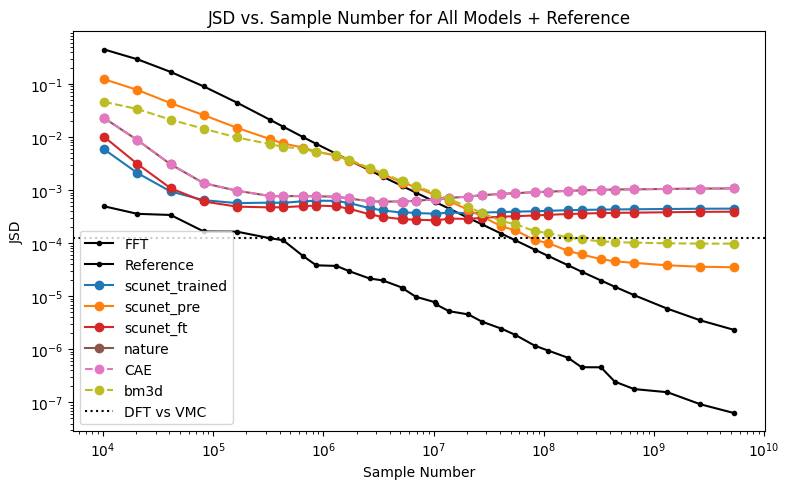

In [32]:
# ================= Plot =================
import logging
logging.getLogger('matplotlib').setLevel(logging.WARNING)
plt.figure(figsize=(8, 5))
x_values, y_values = zip(*model_results_FFT)
# === Plot ===
logging.getLogger('matplotlib').setLevel(logging.WARNING)
plt.figure(figsize=(8, 5))

plt.loglog(x_values, y_values,
           marker=".",             # Dot markers
           linestyle="-",          # Solid connecting line
           color="black", 
           label="FFT")
colors = plt.cm.tab10(np.linspace(0, 1, len(models) + 1))  # +1 for ref

# Plot reference first
plt.loglog(results_array_ref[:, 0], results_array_ref[:, 1],
           marker=".", linestyle="-", color="black", label="Reference")

# Plot each model
for color, model_name in zip(colors, models):
    results_array = np.array(sorted(results_dict[model_name], key=lambda x: x[0]))
    linestyle = "--" if model_name in ["CAE", "bm3d"] else "-"  # dotted for some
    plt.loglog(results_array[:, 0], results_array[:, 1],
               marker="o", linestyle=linestyle, label=model_name, color=color)

plt.xlabel("Sample Number")
plt.ylabel("JSD")
plt.axhline(DFT_vs_VMC, color="black", linestyle=":", label="DFT vs VMC")
plt.title("JSD vs. Sample Number for All Models + Reference")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
print("here")

In [15]:
import numpy as np

# Convert dict-of-pairs into dict-of-arrays so it saves cleanly
results_dict_arrays = {
    name: np.array(sorted(results_dict[name], key=lambda x: x[0]), dtype=float)
    for name in models
}

np.savez_compressed(
    "jsd_plot_data_full_range.npz",
    model_results_FFT=np.array(model_results_FFT, dtype=float),
    results_array_ref=np.array(results_array_ref, dtype=float),
    models=np.array(models),
    DFT_vs_VMC=float(DFT_vs_VMC),
    **{f"results_{k}": v for k, v in results_dict_arrays.items()}
)


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import logging
data = np.load("jsd_plot_data_full_range.npz", allow_pickle=True)

model_results_FFT = [tuple(x) for x in data["model_results_FFT"]]
results_array_ref = data["results_array_ref"]
models = list(data["models"])
DFT_vs_VMC = float(data["DFT_vs_VMC"])

results_dict = {m: data[f"results_{m}"] for m in models}  # each is an (N,2) array

# Reconstruct variables
model_results_FFT = [tuple(x) for x in data["model_results_FFT"]]
results_array_ref = data["results_array_ref"]
models = list(data["models"])
DFT_vs_VMC = float(data["DFT_vs_VMC"])

# Rebuild results_dict (each entry is (N,2))
results_dict = {m: data[f"results_{m}"] for m in models}



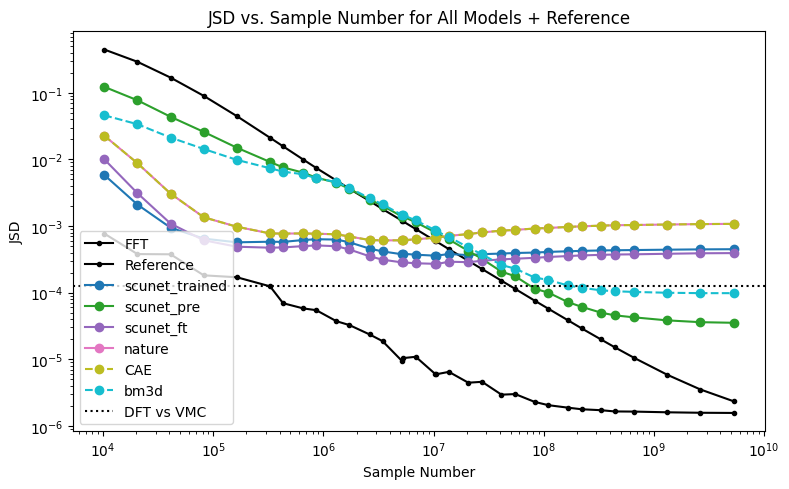

In [13]:
# ================= Plot =================
logging.getLogger('matplotlib').setLevel(logging.WARNING)

plt.figure(figsize=(8, 5))

# ---- FFT curve ----
x_values, y_values = zip(*model_results_FFT)
plt.loglog(
    x_values,
    y_values,
    marker=".",
    linestyle="-",
    color="black",
    label="FFT",
)

# ---- Reference curve ----
plt.loglog(
    results_array_ref[:, 0],
    results_array_ref[:, 1],
    marker=".",
    linestyle="-",
    color="black",
    label="Reference",
)

# ---- Model curves ----
colors = plt.cm.tab10(np.linspace(0, 1, len(models)))

for color, model_name in zip(colors, models):
    results_array = results_dict[model_name]

    # Ensure sorted by sample number
    results_array = results_array[np.argsort(results_array[:, 0])]

    linestyle = "--" if model_name in ["CAE", "bm3d"] else "-"

    plt.loglog(
        results_array[:, 0],
        results_array[:, 1],
        marker="o",
        linestyle=linestyle,
        label=model_name,
        color=color,
    )

# ---- Decorations ----
plt.axhline(
    DFT_vs_VMC,
    color="black",
    linestyle=":",
    label="DFT vs VMC",
)

plt.xlabel("Sample Number")
plt.ylabel("JSD")
plt.title("JSD vs. Sample Number for All Models + Reference")
plt.legend()
plt.tight_layout()
plt.show()


In [18]:
# To load it back later
loaded_data = np.load('/pscratch/sd/k/kberard/SCGSR/3D_VMC/Model_Train_dat/Transformed_Tests/JSD_data.npy', allow_pickle=True).item()
print(loaded_data.keys())

dict_keys(['scunet_pre', 'bm3d'])


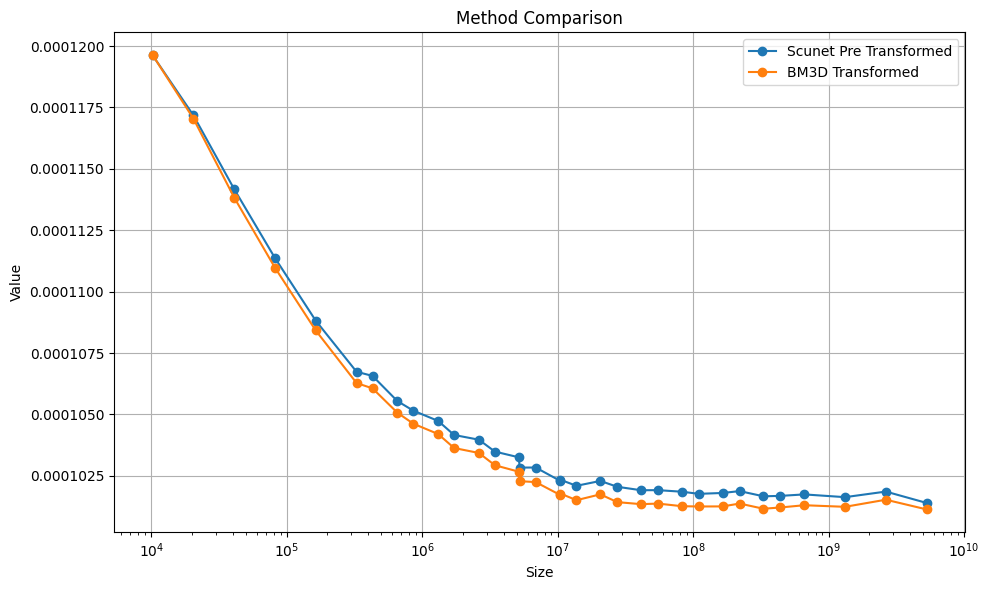

In [20]:
import matplotlib.pyplot as plt
import numpy as np



# Plot
plt.figure(figsize=(10,6))
for method, values in loaded_data.items():
    if method == 'scunet_pre':
        
        x = [v[0] for v in values]
        y = [v[1] for v in values]
        plt.plot(x, y, marker='o', label='Scunet Pre Transformed')
    else:
        x = [v[0] for v in values]
        y = [v[1] for v in values]
        plt.plot(x, y, marker='o', label='BM3D Transformed')


plt.xscale('log')
plt.xlabel('Size')
plt.ylabel('Value')
plt.title('Method Comparison')
plt.legend()
plt.grid(True)
plt.tight_layout()

# Save the figure
plt.savefig('method_comparison.png', dpi=300)
plt.show()


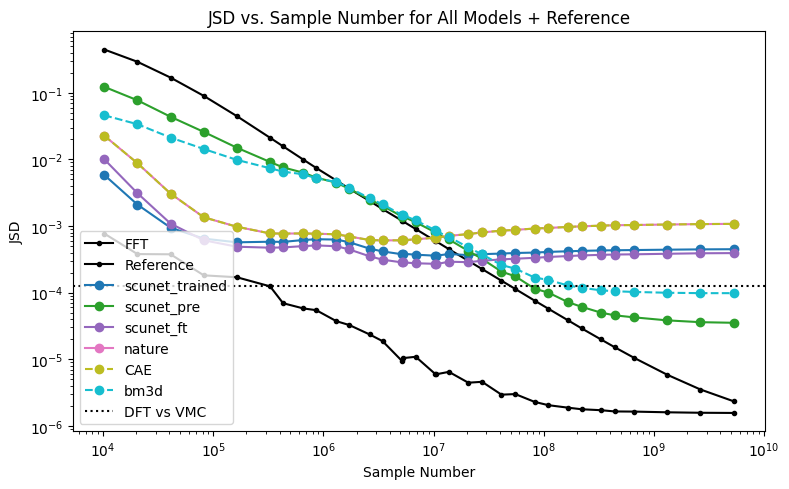

In [21]:
# ================= Plot =================
logging.getLogger('matplotlib').setLevel(logging.WARNING)

plt.figure(figsize=(8, 5))

# ---- FFT curve ----
x_values, y_values = zip(*model_results_FFT)
plt.loglog(
    x_values,
    y_values,
    marker=".",
    linestyle="-",
    color="black",
    label="FFT",
)

# ---- Reference curve ----
plt.loglog(
    results_array_ref[:, 0],
    results_array_ref[:, 1],
    marker=".",
    linestyle="-",
    color="black",
    label="Reference",
)

# ---- Model curves ----
colors = plt.cm.tab10(np.linspace(0, 1, len(models)))

for color, model_name in zip(colors, models):
    results_array = results_dict[model_name]

    # Ensure sorted by sample number
    results_array = results_array[np.argsort(results_array[:, 0])]

    linestyle = "--" if model_name in ["CAE", "bm3d"] else "-"

    plt.loglog(
        results_array[:, 0],
        results_array[:, 1],
        marker="o",
        linestyle=linestyle,
        label=model_name,
        color=color,
    )

# ---- Decorations ----
plt.axhline(
    DFT_vs_VMC,
    color="black",
    linestyle=":",
    label="DFT vs VMC",
)

plt.xlabel("Sample Number")
plt.ylabel("JSD")
plt.title("JSD vs. Sample Number for All Models + Reference")
plt.legend()
plt.tight_layout()
plt.show()


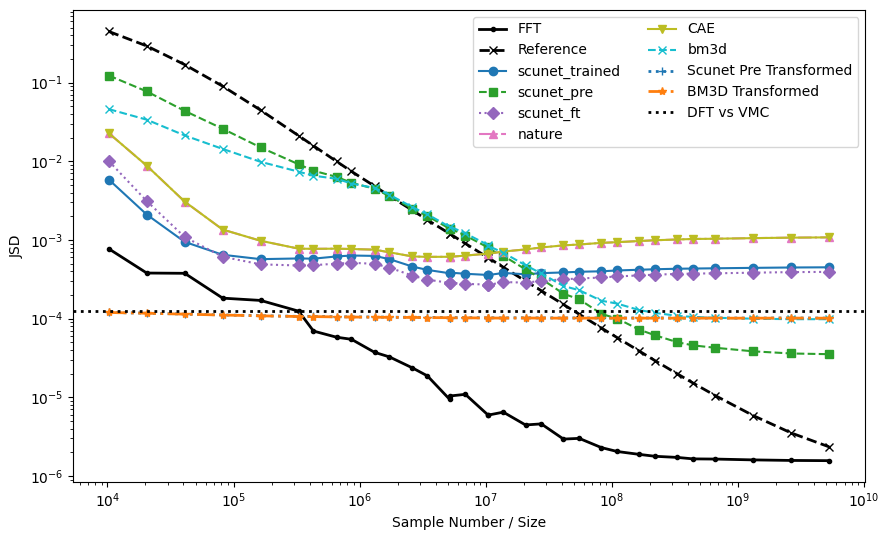

In [24]:
import matplotlib.pyplot as plt
import numpy as np
import logging

logging.getLogger('matplotlib').setLevel(logging.WARNING)

plt.figure(figsize=(9, 5.5))

# ---------------- Style pools ----------------
markers = ["o", "s", "D", "^", "v", "x", "+", "*", "P", "<", ">"]
linestyles = ["-", "--", ":", "-."]

marker_idx = 0
line_idx = 0

# ---------------- FFT ----------------
x_fft, y_fft = zip(*model_results_FFT)
plt.loglog(
    x_fft,
    y_fft,
    marker=".",
    linestyle="-",
    color="black",
    linewidth=2,
    label="FFT",
)

# ---------------- Reference ----------------
plt.loglog(
    results_array_ref[:, 0],
    results_array_ref[:, 1],
    marker="x",
    linestyle="--",
    color="black",
    linewidth=2,
    label="Reference",
)

# ---------------- Main ML models ----------------
colors = plt.cm.tab10(np.linspace(0, 1, len(models)))

for color, model_name in zip(colors, models):
    results_array = results_dict[model_name]
    results_array = results_array[np.argsort(results_array[:, 0])]

    plt.loglog(
        results_array[:, 0],
        results_array[:, 1],
        marker=markers[marker_idx % len(markers)],
        linestyle=linestyles[line_idx % len(linestyles)],
        color=color,
        label=model_name,
    )

    marker_idx += 1
    line_idx += 1

# ---------------- Transformed methods (from loaded_data) ----------------
for method, values in loaded_data.items():
    x = np.array([v[0] for v in values])
    y = np.array([v[1] for v in values])

    label = (
        "Scunet Pre Transformed"
        if method == "scunet_pre"
        else "BM3D Transformed"
    )

    plt.loglog(
        x,
        y,
        marker=markers[marker_idx % len(markers)],
        linestyle=linestyles[line_idx % len(linestyles)],
        linewidth=2,
        label=label,
    )

    marker_idx += 1
    line_idx += 1

# ---------------- DFT vs VMC line ----------------
plt.axhline(
    DFT_vs_VMC,
    color="black",
    linestyle=":",
    linewidth=2,
    label="DFT vs VMC",
)

# ---------------- Decorations ----------------
plt.xlabel("Sample Number / Size")
plt.ylabel("JSD")
plt.legend(ncol=2)
plt.tight_layout()
plt.show()


In [25]:
# ================= Save all plot data =================
plot_data = {}

# ---- FFT ----
plot_data["FFT"] = {
    "x": np.array(x_fft),
    "y": np.array(y_fft),
}

# ---- Reference ----
plot_data["Reference"] = {
    "x": results_array_ref[:, 0],
    "y": results_array_ref[:, 1],
}

# ---- Main ML models ----
for model_name in models:
    arr = results_dict[model_name]
    arr = arr[np.argsort(arr[:, 0])]

    plot_data[model_name] = {
        "x": arr[:, 0],
        "y": arr[:, 1],
    }

# ---- Transformed methods (Scunet / BM3D) ----
for method, values in loaded_data.items():
    x = np.array([v[0] for v in values])
    y = np.array([v[1] for v in values])

    key = (
        "Scunet_Pre_Transformed"
        if method == "scunet_pre"
        else "BM3D_Transformed"
    )

    plot_data[key] = {
        "x": x,
        "y": y,
    }

# ---- DFT vs VMC threshold ----
plot_data["DFT_vs_VMC"] = {
    "value": DFT_vs_VMC
}

# ---- Save ----
np.save("image_plus_trans.npy", plot_data, allow_pickle=True)
